# 헤이빗 리텐션 분석 — PPT 슬라이드별 시각화 코드 (v3)

> **v2 → v3 변경점:** 자체 전처리를 제거하고, 실제 전처리 완료 파일
> `user_profile_preprocessed.csv` / `event_log_preprocessed.csv`를 그대로 로드.
> `is_log_anomaly` 컬럼도 파일에 이미 포함된 값을 그대로 사용.

실행 순서: 셀 0(환경설정) → 셀 1(전처리 파일 로드) → 셀 2(리텐션 계산, 장애제외 핵심 로직) → 슬라이드별 셀 순서대로

## 셀 0 — 환경 설정

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as mtick
import seaborn as sns
from scipy.stats import chi2_contingency, ttest_ind
import warnings
warnings.filterwarnings("ignore")

# ── 한글 폰트 ──
font_path = "C:/Windows/Fonts/malgun.ttf"  # Mac: /System/Library/Fonts/AppleSDGothicNeo.ttc
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = fm.FontProperties(fname=font_path).get_name()
plt.rcParams["axes.unicode_minus"] = False

# ── 컬러 팔레트 ──
TEAL   = "#028090"
MINT   = "#02C39A"
DANGER = "#E05C4B"
WARN   = "#E8A020"
MID    = "#4A6274"
DARK   = "#0D1F2D"
LIGHT  = "#F2F8FA"

def cramers_v(ct):
    chi2, _, _, _ = chi2_contingency(ct)
    n = ct.sum().sum()
    return round(float(np.sqrt(chi2 / (n * (min(ct.shape) - 1)))), 3)

print("환경 설정 완료")


환경 설정 완료


## 셀 1 — 전처리 완료 파일 로드
`00_preprocessed.ipynb`에서 만든 결과물을 그대로 사용. 재전처리하지 않음.

In [2]:

DATA_DIR = "../../DATA"   # 본인 환경에 맞게 수정 (대소문자 주의)

up = pd.read_csv(f"{DATA_DIR}/user_profile_preprocessed.csv")
el = pd.read_csv(f"{DATA_DIR}/event_log_preprocessed.csv")

print(f"user_profile_preprocessed.csv: {up.shape}")
print(f"event_log_preprocessed.csv: {el.shape}")

# ── 날짜 컬럼 datetime 변환 (파일엔 문자열로 저장되어 있음) ──
up["가입일자"] = pd.to_datetime(up["가입일자"])
up["가입일"]   = pd.to_datetime(up["가입일"])
up["User_ID"]  = up["User_ID"].astype(str)

el["Event_Time"] = pd.to_datetime(el["Event_Time"])
el["Event_Date"] = pd.to_datetime(el["Event_Date"])
el["User_ID"]    = el["User_ID"].astype(str)

up["cohort"] = up["가입일자"].dt.to_period("M").astype(str)

# ── Event_Type 결측 제거 (분석 제외) ──
el_clean = el.dropna(subset=["Event_Type"]).copy()
print(f"Event_Type 결측 제거: {len(el):,} → {len(el_clean):,}  ({len(el)-len(el_clean):,}건 제외)")

# ── 알림 이벤트 분리 (활성 판단 제외) ──
NOTI_TYPES = ["알림수신", "알림오픈"]
el_act  = el_clean[~el_clean["Event_Type"].isin(NOTI_TYPES)].copy()
el_noti = el_clean[ el_clean["Event_Type"].isin(NOTI_TYPES)].copy()

# ── 앱실행 이벤트 (리텐션 계산 기준) ──
el_launch = el_act[el_act["Event_Type"] == "앱실행"].copy()
launch_set = set(zip(el_launch["User_ID"], el_launch["Event_Date"]))

# ── 로그 장애 구간 (파일에 이미 있는 is_log_anomaly 컬럼으로 검증) ──
anomaly_dates = sorted(el_clean[el_clean["is_log_anomaly"]==True]["Event_Date"].dt.strftime("%Y-%m-%d").unique())
print(f"\nis_log_anomaly=True 날짜: {anomaly_dates}")
FAULT_START = pd.Timestamp(anomaly_dates[0])
FAULT_END   = pd.Timestamp(anomaly_dates[-1])
print(f"장애 구간: {FAULT_START.date()} ~ {FAULT_END.date()}")

print(f"\n유저: {len(up):,}명 / 전체이벤트: {len(el):,}건")
print(f"앱실행: {len(el_launch):,}건 / 알림: {len(el_noti):,}건")
print(f"완전 미활동 유저: {len(set(up['User_ID']) - set(el['User_ID'])):,}명")


user_profile_preprocessed.csv: (12500, 10)
event_log_preprocessed.csv: (1757262, 11)
Event_Type 결측 제거: 1,757,262 → 1,730,806  (26,456건 제외)

is_log_anomaly=True 날짜: ['2025-03-10', '2025-03-11', '2025-03-12', '2025-03-13', '2025-03-14']
장애 구간: 2025-03-10 ~ 2025-03-14

유저: 12,500명 / 전체이벤트: 1,757,262건
앱실행: 728,657건 / 알림: 215,543건
완전 미활동 유저: 47명


## 셀 2 — 리텐션 계산 (★ 로그 장애 보정 핵심 로직)

**원칙:** 가입일+N일(체크 시점)이 장애기간과 겹치는 유저는 해당 일자 리텐션 계산에서 **NaN 처리(분모 제외)**.

- `exclude_fault=True` (기본값, 모든 본 분석에 사용)
- `exclude_fault=False` (민감도 확인용으로만 별도 산출, 결론에는 사용하지 않음)

In [3]:

def calc_retention(day, exclude_fault=True):
    df = up[["User_ID", "가입일"]].copy()
    df["target"] = df["가입일"] + pd.Timedelta(days=day)
    r = df.apply(lambda x: int((x["User_ID"], x["target"]) in launch_set), axis=1).astype(float)
    if exclude_fault:
        is_faulted = df["target"].between(FAULT_START, FAULT_END)
        r = r.where(~is_faulted, np.nan)
    return r

# ── 본 분석용 (장애 제외) ──
ret = up[["User_ID","가입일","cohort","가입경로","기기","알림수신동의여부"]].copy()
for d in [0, 3, 7, 30]:
    ret[f"d{d}"] = calc_retention(d, exclude_fault=True)

# ── 민감도 확인용 (장애 포함) ──
ret_incl = up[["User_ID","가입일","cohort"]].copy()
for d in [0, 3, 7, 30]:
    ret_incl[f"d{d}"] = calc_retention(d, exclude_fault=False)

# ── 기능 경험 여부 (전체기간 기준) ──
for feat in ["수면기록","운동기록","마음챙김","식단기록","챌린지참여","챌린지_탐색","온보딩_완료"]:
    ids = set(el_act[el_act["Event_Type"]==feat]["User_ID"])
    ret[f"has_{feat}"] = ret["User_ID"].isin(ids).astype(int)

ret["category_cnt"] = ret[["has_수면기록","has_운동기록","has_마음챙김","has_식단기록"]].sum(axis=1)
ret["ob_ch"] = ret["has_온보딩_완료"].astype(str) + "_" + ret["has_챌린지참여"].astype(str)

print("=== 전체 리텐션: 장애포함 vs 장애제외 (민감도 확인) ===")
for d in [0,3,7,30]:
    incl = ret_incl[f"d{d}"].mean()*100
    excl = ret[f"d{d}"].mean()*100
    print(f"  D{d:2d}: 포함 {incl:5.1f}%   |   제외 {excl:5.2f}%  (본 분석 기본값)")

print("\n=== 코호트별 (장애제외 기준) ===")
cs = ret.groupby("cohort")[["d0","d3","d7","d30"]].mean()*100
cs["n"] = ret.groupby("cohort").size()
print(cs.round(2))

# 본 분석 핵심 서브셋
sub30 = ret.dropna(subset=["d30"])
sub37 = ret.dropna(subset=["d3","d7"])


=== 전체 리텐션: 장애포함 vs 장애제외 (민감도 확인) ===
  D 0: 포함  98.0%   |   제외 99.82%  (본 분석 기본값)
  D 3: 포함  71.7%   |   제외 73.07%  (본 분석 기본값)
  D 7: 포함  42.2%   |   제외 43.13%  (본 분석 기본값)
  D30: 포함  24.3%   |   제외 25.09%  (본 분석 기본값)

=== 코호트별 (장애제외 기준) ===
            d0     d3     d7    d30     n
cohort                                   
2025-01  99.81  70.57  39.97  22.60  2124
2025-02  99.79  76.28  46.99  32.60  4384
2025-03  99.66  72.32  41.85  23.00  2122
2025-04  99.90  70.17  40.30  20.75  2082
2025-05  99.94  72.26  41.95  20.41  1788


---
## 3장 — 문제 정의 : D30 추이 꺾은선 그래프

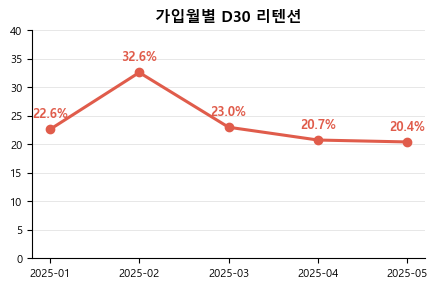

In [4]:

cs = ret.groupby("cohort")[["d0","d3","d7","d30"]].mean() * 100
months = cs.index.tolist()
vals   = cs["d30"].tolist()

fig, ax = plt.subplots(figsize=(4.5, 3))
ax.plot(months, vals, color=DANGER, marker="o", lw=2.2, ms=6)
for x, y in zip(months, vals):
    ax.annotate(f"{y:.1f}%", (x, y), textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=9, color=DANGER, fontweight="bold")

ax.set_ylim(0, 40)
ax.set_title("가입월별 D30 리텐션", fontsize=11, fontweight="bold")
ax.spines[["top","right"]].set_visible(False)
ax.tick_params(labelsize=8)
ax.grid(axis="y", alpha=0.3, lw=0.7)
plt.tight_layout()
plt.savefig("slide03_d30_trend.png", dpi=180, bbox_inches="tight")
plt.show()


---
## 5장 — 1차 EDA ① : 전체 리텐션 현황

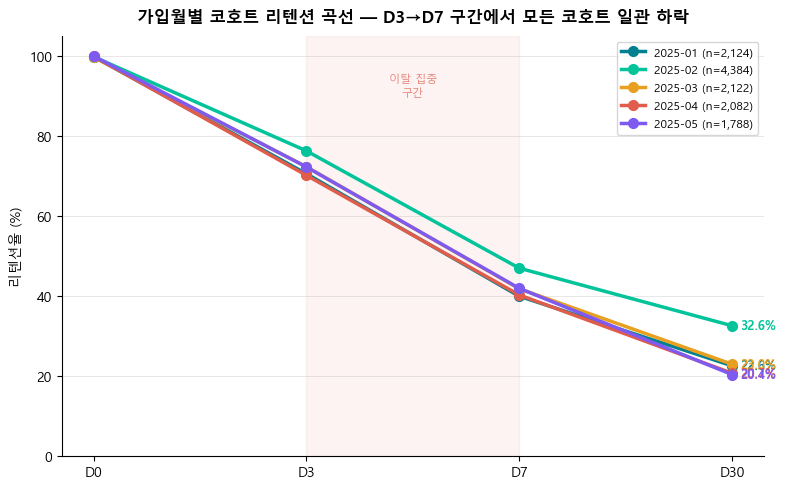

In [5]:

# ── 시각화 1 : 코호트 리텐션 곡선 ──
cs = ret.groupby("cohort")[["d0","d3","d7","d30"]].mean() * 100
cs["n"] = ret.groupby("cohort").size()

fig, ax = plt.subplots(figsize=(8, 5))
colors = [TEAL, MINT, WARN, DANGER, "#7F5AF0"]
xticks = ["D0","D3","D7","D30"]

for i, (month, row) in enumerate(cs.iterrows()):
    vals = [row["d0"], row["d3"], row["d7"], row["d30"]]
    ax.plot(xticks, vals, marker="o", lw=2.5, ms=7,
            color=colors[i], label=f"{month} (n={int(row['n']):,})")
    ax.annotate(f"{row['d30']:.1f}%", xy=("D30", row["d30"]),
                xytext=(6, 0), textcoords="offset points",
                color=colors[i], fontsize=9, va="center", fontweight="bold")

ax.axvspan("D3", "D7", alpha=0.07, color=DANGER, zorder=0)
ax.text(1.5, 90, "이탈 집중\n구간", ha="center", fontsize=8, color=DANGER, alpha=0.75)
ax.set_ylim(0, 105)
ax.set_title("가입월별 코호트 리텐션 곡선 — D3→D7 구간에서 모든 코호트 일관 하락",
             fontsize=12, fontweight="bold", pad=10)
ax.set_ylabel("리텐션율 (%)")
ax.legend(loc="upper right", fontsize=8.5)
ax.grid(axis="y", alpha=0.3, lw=0.7)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("slide05_cohort_curve.png", dpi=180, bbox_inches="tight")
plt.show()


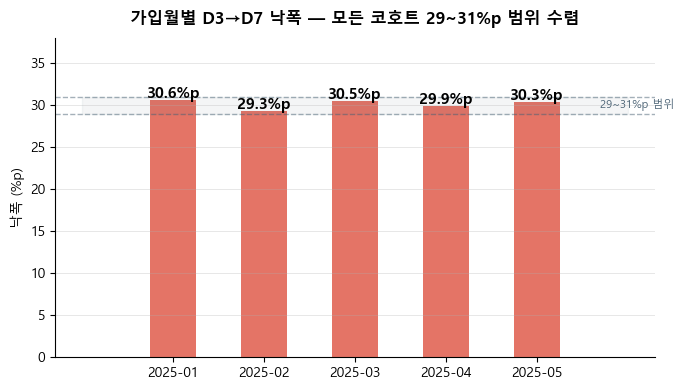

In [6]:

# ── 시각화 2 : D3→D7 낙폭 바차트 ──
cs["drop_d3_d7"] = cs["d3"] - cs["d7"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(cs.index, cs["drop_d3_d7"], color=DANGER, alpha=0.85, width=0.5)
for bar, val in zip(bars, cs["drop_d3_d7"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f"{val:.1f}%p", ha="center", fontsize=11, fontweight="bold")
ax.axhline(29, ls="--", color=MID, lw=1, alpha=0.5)
ax.axhline(31, ls="--", color=MID, lw=1, alpha=0.5)
ax.fill_between(range(-1, len(cs)+1), 29, 31, alpha=0.06, color=MID)
ax.text(len(cs)-0.3, 30, "29~31%p 범위", fontsize=8, color=MID, va="center")
ax.set_ylim(0, 38)
ax.set_title("가입월별 D3→D7 낙폭 — 모든 코호트 29~31%p 범위 수렴",
             fontsize=12, fontweight="bold", pad=10)
ax.set_ylabel("낙폭 (%p)")
ax.grid(axis="y", alpha=0.3, lw=0.7)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("slide05_d3d7_drop.png", dpi=180, bbox_inches="tight")
plt.show()


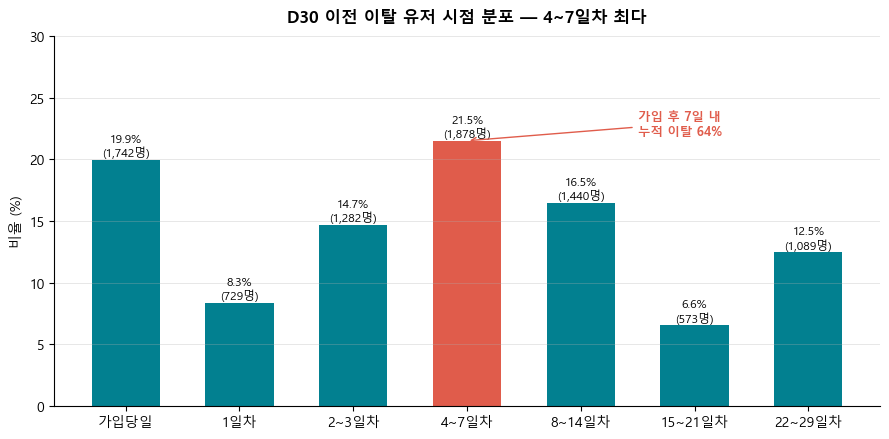

In [7]:

# ── 시각화 3 : 이탈 시점 분포 ──
churned_ids = set(sub30[sub30["d30"]==0]["User_ID"])

el_j = el_launch.merge(up[["User_ID","가입일"]], on="User_ID", how="left")
el_j["days"] = (el_j["Event_Date"] - el_j["가입일"]).dt.days

last_day = (
    el_j[el_j["days"].between(0, 29)]
    .groupby("User_ID")["days"].max()
    .reset_index(name="last_day")
)
churned = pd.DataFrame({"User_ID": list(churned_ids)}).merge(last_day, on="User_ID", how="left")
churned["bucket"] = pd.cut(
    churned["last_day"],
    bins=[-1,0,1,3,7,14,21,29],
    labels=["가입당일","1일차","2~3일차","4~7일차","8~14일차","15~21일차","22~29일차"]
)
dist = churned["bucket"].value_counts().sort_index()
pct  = dist / dist.sum() * 100

fig, ax = plt.subplots(figsize=(9, 4.5))
bar_colors = [TEAL if b != "4~7일차" else DANGER for b in pct.index]
bars = ax.bar(pct.index, pct.values, color=bar_colors, width=0.6)
for bar, p, c in zip(bars, pct.values, dist.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f"{p:.1f}%\n({c:,}명)", ha="center", fontsize=8.5)
ax.set_ylim(0, 30)
ax.set_title("D30 이전 이탈 유저 시점 분포 — 4~7일차 최다",
             fontsize=12, fontweight="bold", pad=10)
ax.set_ylabel("비율 (%)")
ax.grid(axis="y", alpha=0.3, lw=0.7)
ax.spines[["top","right"]].set_visible(False)

cum = pct.iloc[:4].sum()
ax.annotate(f"가입 후 7일 내\n누적 이탈 {cum:.0f}%",
            xy=(3, pct.iloc[3]), xytext=(4.5, 22),
            arrowprops=dict(arrowstyle="->", color=DANGER),
            fontsize=9, color=DANGER, fontweight="bold")
plt.tight_layout()
plt.savefig("slide05_churn_timing.png", dpi=180, bbox_inches="tight")
plt.show()


---
## 6장 — 1차 EDA ② : 대립 변수 기각 (채널/기기/알림동의)

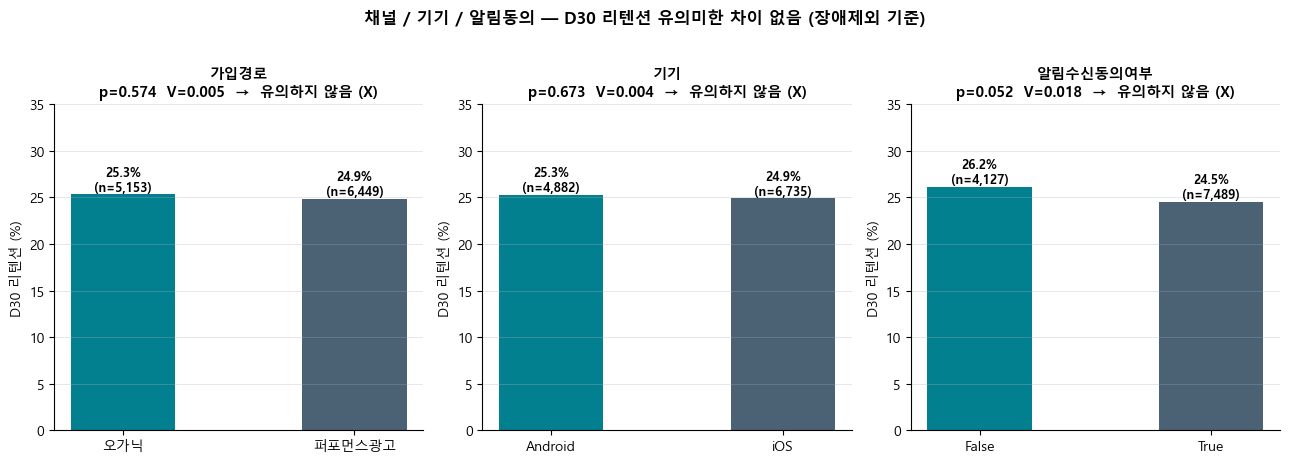

In [8]:

segs = {"가입경로":"가입경로", "기기":"기기", "알림수신동의여부":"알림수신동의여부"}

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, (title, col) in zip(axes, segs.items()):
    sub_col = sub30.dropna(subset=[col])
    grp = sub_col.groupby(col)["d30"].agg(["mean","count"]).reset_index()
    grp["D30"] = grp["mean"] * 100

    ct = pd.crosstab(sub_col[col], sub_col["d30"])
    chi2, p, _, _ = chi2_contingency(ct)
    v = cramers_v(ct)

    bar_colors = [TEAL, MID]
    bars = ax.bar(grp[col].astype(str), grp["D30"],
                  color=bar_colors[:len(grp)], width=0.45)
    for bar, row in zip(bars, grp.itertuples()):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
                f"{row.D30:.1f}%\n(n={row.count:,})",
                ha="center", fontsize=9, fontweight="bold")

    sig = "유의하지 않음 (X)" if p > 0.05 else "유의함 (O)"
    ax.set_title(f"{title}\np={p:.3f}  V={v:.3f}  →  {sig}",
                 fontsize=10.5, fontweight="bold")
    ax.set_ylim(0, 35)
    ax.set_ylabel("D30 리텐션 (%)")
    ax.grid(axis="y", alpha=0.3, lw=0.7)
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle("채널 / 기기 / 알림동의 — D30 리텐션 유의미한 차이 없음 (장애제외 기준)",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("slide06_segment_d30.png", dpi=180, bbox_inches="tight")
plt.show()


---
## 7장 — 1차 EDA ③ : 챌린지·온보딩 분포 탐색

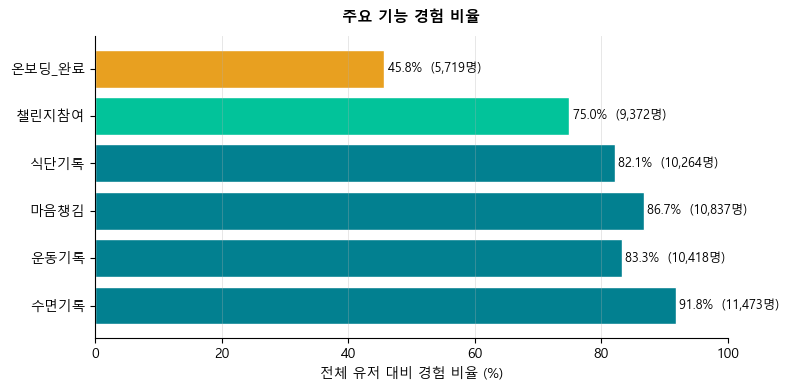

In [9]:

# ── 시각화 1 : 주요 기능 경험 비율 ──
feats = ["수면기록","운동기록","마음챙김","식단기록","챌린지참여","온보딩_완료"]
feat_cnt = {f: ret[f"has_{f}"].sum() for f in feats}
feat_pct = {f: v/len(ret)*100 for f,v in feat_cnt.items()}

fig, ax = plt.subplots(figsize=(8, 4))
colors_f = [TEAL]*4 + [MINT, WARN]
bars = ax.barh(list(feat_cnt.keys()), list(feat_pct.values()), color=colors_f, edgecolor="white")
for bar, (feat, pct) in zip(bars, feat_pct.items()):
    ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
            f"{pct:.1f}%  ({feat_cnt[feat]:,}명)", va="center", fontsize=9)
ax.set_xlim(0, 100)
ax.set_xlabel("전체 유저 대비 경험 비율 (%)")
ax.set_title("주요 기능 경험 비율", fontsize=11, fontweight="bold", pad=10)
ax.grid(axis="x", alpha=0.3, lw=0.7)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("slide07_feature_rate.png", dpi=180, bbox_inches="tight")
plt.show()


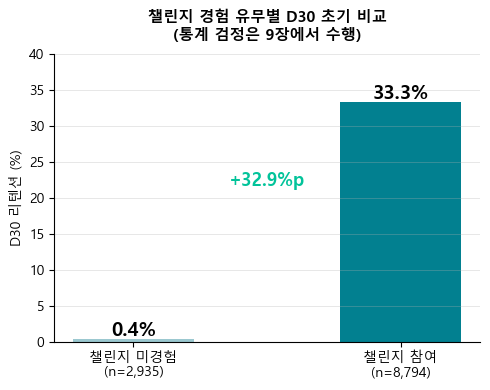

In [10]:

# ── 시각화 2 : 챌린지 경험 유무별 D30 초기 비교 (장애제외) ──
grp = sub30.groupby("has_챌린지참여")["d30"].mean() * 100
n0 = sub30[sub30["has_챌린지참여"]==0].shape[0]
n1 = sub30[sub30["has_챌린지참여"]==1].shape[0]
labels = [f"챌린지 미경험\n(n={n0:,})", f"챌린지 참여\n(n={n1:,})"]

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(labels, grp.values, color=["#9BC8D0", TEAL], width=0.45)
for bar, val in zip(bars, grp.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
            f"{val:.1f}%", ha="center", fontsize=14, fontweight="bold")
diff = grp.values[1] - grp.values[0]
ax.annotate(f"+{diff:.1f}%p", xy=(0.5, grp.values[1]/2+5),
            xycoords=("axes fraction","data"),
            fontsize=13, color=MINT, fontweight="bold", ha="center")
ax.set_ylim(0, 40)
ax.set_ylabel("D30 리텐션 (%)")
ax.set_title("챌린지 경험 유무별 D30 초기 비교\n(통계 검정은 9장에서 수행)",
             fontsize=11, fontweight="bold", pad=10)
ax.grid(axis="y", alpha=0.3, lw=0.7)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("slide07_challenge_preview.png", dpi=180, bbox_inches="tight")
plt.show()


---
## 8장 — 1차 EDA ④ : 이탈 유저 행동 패턴 + 기능 다양성 + 위기그룹

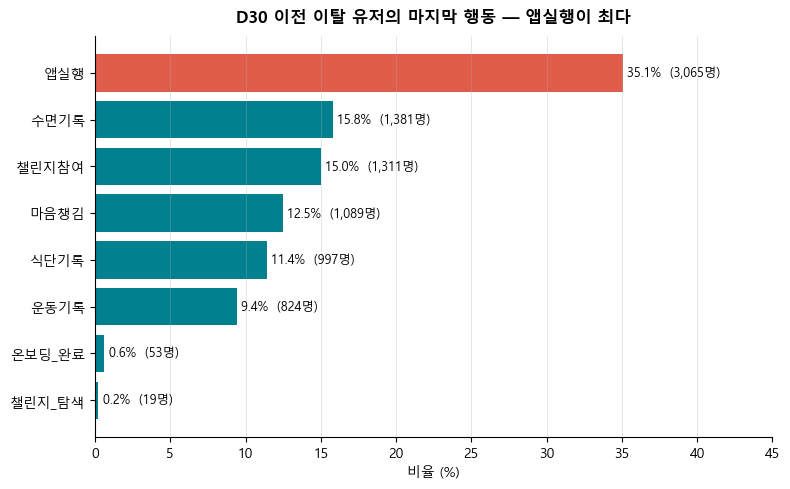

In [11]:

# ── 시각화 1 : 이탈 유저 마지막 행동 ──
el_ch = el_act[el_act["User_ID"].isin(churned_ids)].copy()
el_ch = el_ch.merge(up[["User_ID","가입일"]], on="User_ID", how="left")
el_ch["days"] = (el_ch["Event_Date"] - el_ch["가입일"]).dt.days
el_ch29 = el_ch[el_ch["days"].between(0,29)]

last_act = (
    el_ch29.sort_values("Event_Time")
    .groupby("User_ID")["Event_Type"].last()
    .reset_index(name="last_type")
)
la_dist = last_act["last_type"].value_counts()
la_pct  = la_dist / la_dist.sum() * 100

fig, ax = plt.subplots(figsize=(8, 5))
pct_s = la_pct.sort_values()
bar_colors = [DANGER if v == pct_s.max() else TEAL for v in pct_s]
bars = ax.barh(pct_s.index, pct_s.values, color=bar_colors)
for bar, pct, cnt in zip(bars, pct_s.values, [la_dist[i] for i in pct_s.index]):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
            f"{pct:.1f}%  ({cnt:,}명)", va="center", fontsize=9)
ax.set_xlim(0, 45)
ax.set_title("D30 이전 이탈 유저의 마지막 행동 — 앱실행이 최다",
             fontsize=12, fontweight="bold", pad=10)
ax.set_xlabel("비율 (%)")
ax.grid(axis="x", alpha=0.3, lw=0.7)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("slide08_last_action.png", dpi=180, bbox_inches="tight")
plt.show()


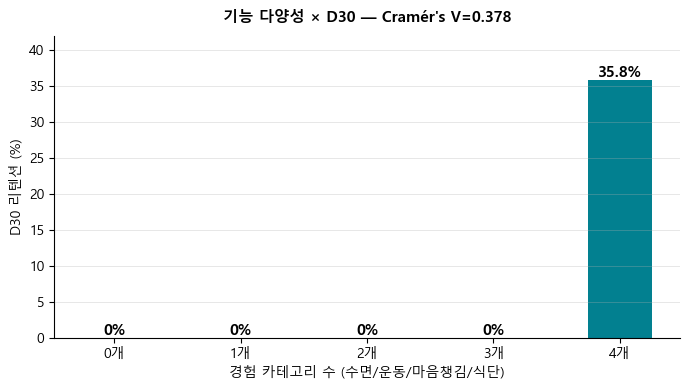

In [12]:

# ── 시각화 2 : 기능 다양성 × D30 (장애제외) ──
cat_ret = sub30.groupby("category_cnt").agg(
    n=("User_ID","count"), d30=("d30","mean")
).reset_index()
cat_ret["D30"] = cat_ret["d30"] * 100

ct_cat = pd.crosstab(sub30["category_cnt"], sub30["d30"])
v_cat = cramers_v(ct_cat)

fig, ax = plt.subplots(figsize=(7, 4))
bar_c = ["#9BC8D0"]*4 + [TEAL]
bars = ax.bar(cat_ret["category_cnt"].astype(str)+"개", cat_ret["D30"], color=bar_c, width=0.5)
for bar, row in zip(bars, cat_ret.itertuples()):
    label = f"{row.D30:.1f}%" if row.D30 > 0 else "0%"
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            label, ha="center", fontsize=11, fontweight="bold")
ax.set_ylim(0, 42)
ax.set_xlabel("경험 카테고리 수 (수면/운동/마음챙김/식단)")
ax.set_ylabel("D30 리텐션 (%)")
ax.set_title(f"기능 다양성 × D30 — Cramér's V={v_cat:.3f}",
             fontsize=11, fontweight="bold", pad=10)
ax.grid(axis="y", alpha=0.3, lw=0.7)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("slide08_feature_diversity.png", dpi=180, bbox_inches="tight")
plt.show()


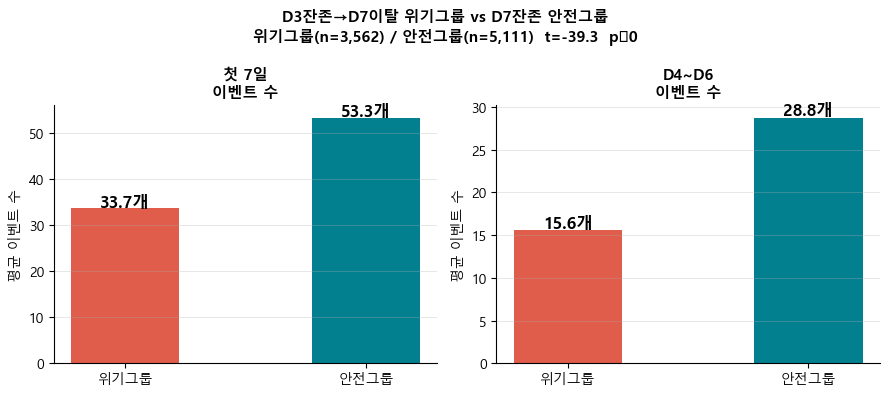

챌린지 경험률 — 위기그룹 72.3% / 안전그룹 93.2%


In [13]:

# ── 시각화 3 : 위기그룹 vs 안전그룹 ──
crisis = set(sub37[(sub37["d3"]==1)&(sub37["d7"]==0)]["User_ID"])
safe   = set(sub37[(sub37["d3"]==1)&(sub37["d7"]==1)]["User_ID"])

el_j2 = el_act.merge(up[["User_ID","가입일"]], on="User_ID", how="left")
el_j2["days"] = (el_j2["Event_Date"] - el_j2["가입일"]).dt.days

def mean_events(ids, day_range):
    sub = el_j2[el_j2["User_ID"].isin(ids) & el_j2["days"].between(*day_range)]
    return sub.groupby("User_ID").size().reindex(list(ids), fill_value=0).mean()

metrics = {
    "첫 7일\n이벤트 수": (mean_events(crisis,(0,6)), mean_events(safe,(0,6))),
    "D4~D6\n이벤트 수": (mean_events(crisis,(3,6)), mean_events(safe,(3,6))),
}

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, (title, (c_val, s_val)) in zip(axes, metrics.items()):
    bars = ax.bar(["위기그룹","안전그룹"], [c_val, s_val], color=[DANGER, TEAL], width=0.45)
    for bar, val in zip(bars, [c_val, s_val]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f"{val:.1f}개", ha="center", fontsize=12, fontweight="bold")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel("평균 이벤트 수")
    ax.grid(axis="y", alpha=0.3, lw=0.7)
    ax.spines[["top","right"]].set_visible(False)

t, p = ttest_ind(
    el_j2[el_j2["User_ID"].isin(crisis)&el_j2["days"].between(0,6)].groupby("User_ID").size(),
    el_j2[el_j2["User_ID"].isin(safe)  &el_j2["days"].between(0,6)].groupby("User_ID").size()
)
plt.suptitle(f"D3잔존→D7이탈 위기그룹 vs D7잔존 안전그룹\n"
             f"위기그룹(n={len(crisis):,}) / 안전그룹(n={len(safe):,})  t={t:.1f}  p≈0",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("slide08_crisis_safe.png", dpi=180, bbox_inches="tight")
plt.show()

ch_rate_crisis = ret[ret["User_ID"].isin(crisis)]["has_챌린지참여"].mean()*100
ch_rate_safe   = ret[ret["User_ID"].isin(safe)]["has_챌린지참여"].mean()*100
print(f"챌린지 경험률 — 위기그룹 {ch_rate_crisis:.1f}% / 안전그룹 {ch_rate_safe:.1f}%")


---
## 9장 — 통계 검정 ① : 챌린지 경험 × D30

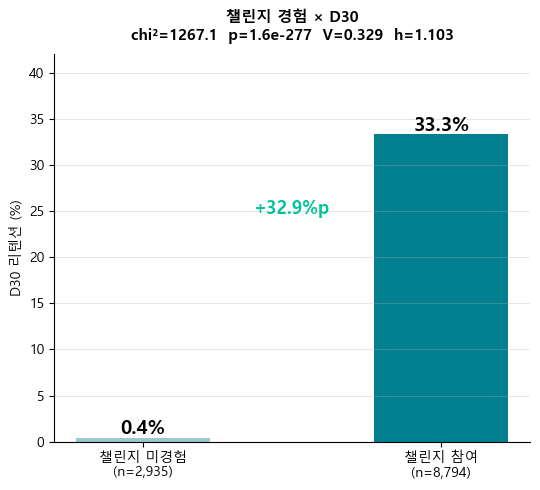

In [14]:

grp = sub30.groupby("has_챌린지참여").agg(
    n=("User_ID","count"), d30=("d30","mean")
).reset_index()

ct = pd.crosstab(sub30["has_챌린지참여"], sub30["d30"])
chi2, p, _, _ = chi2_contingency(ct)
v = cramers_v(ct)
p1, p2 = grp["d30"].iloc[1], grp["d30"].iloc[0]
h = float(2*np.arcsin(np.sqrt(p1)) - 2*np.arcsin(np.sqrt(p2)))

labels = [f"챌린지 미경험\n(n={int(grp['n'].iloc[0]):,})",
          f"챌린지 참여\n(n={int(grp['n'].iloc[1]):,})"]
vals = [p2*100, p1*100]

fig, ax = plt.subplots(figsize=(5.5, 5))
bars = ax.bar(labels, vals, color=["#9BC8D0", TEAL], width=0.45)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
            f"{val:.1f}%", ha="center", fontsize=14, fontweight="bold")
ax.set_ylim(0, 42)
ax.set_ylabel("D30 리텐션 (%)")
ax.set_title(f"챌린지 경험 × D30\nchi²={chi2:.1f}  p={p:.1e}  V={v:.3f}  h={h:.3f}",
             fontsize=11, fontweight="bold", pad=10)
diff = vals[1]-vals[0]
ax.annotate(f"+{diff:.1f}%p", xy=(0.5, vals[1]/2+8),
            xycoords=("axes fraction","data"),
            fontsize=13, color=MINT, fontweight="bold", ha="center")
ax.grid(axis="y", alpha=0.3, lw=0.7)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("slide09_challenge_d30.png", dpi=180, bbox_inches="tight")
plt.show()


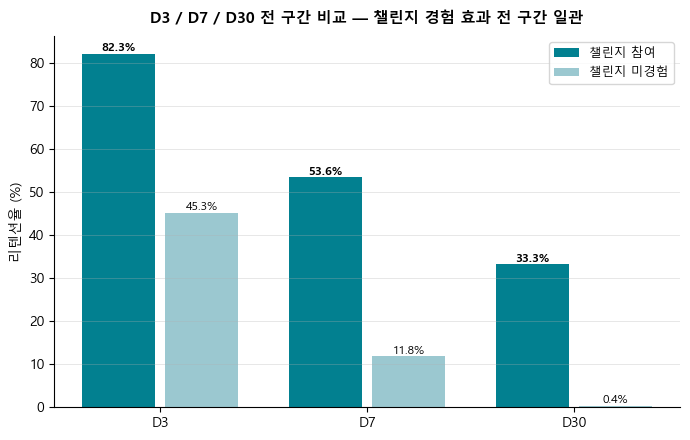

In [15]:

# ── 시각화 2 : D3/D7/D30 전구간 그룹 바차트 ──
d3_grp = sub37.groupby("has_챌린지참여")["d3"].mean()*100
d7_grp = sub37.groupby("has_챌린지참여")["d7"].mean()*100
d30_grp = sub30.groupby("has_챌린지참여")["d30"].mean()*100

days = ["D3","D7","D30"]
ex_vals  = [d3_grp[1], d7_grp[1], d30_grp[1]]
nex_vals = [d3_grp[0], d7_grp[0], d30_grp[0]]
x = np.arange(3)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(x-0.2, ex_vals, 0.35, label="챌린지 참여", color=TEAL)
ax.bar(x+0.2, nex_vals, 0.35, label="챌린지 미경험", color="#9BC8D0")
for i, (e, n) in enumerate(zip(ex_vals, nex_vals)):
    ax.text(i-0.2, e+0.5, f"{e:.1f}%", ha="center", fontsize=8.5, fontweight="bold")
    ax.text(i+0.2, n+0.5, f"{n:.1f}%", ha="center", fontsize=8.5)
ax.set_xticks(x); ax.set_xticklabels(days)
ax.set_ylabel("리텐션율 (%)")
ax.set_title("D3 / D7 / D30 전 구간 비교 — 챌린지 경험 효과 전 구간 일관",
             fontsize=11, fontweight="bold", pad=10)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3, lw=0.7)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("slide09_all_days.png", dpi=180, bbox_inches="tight")
plt.show()


---
## 10장 — 통계 검정 ② : 온보딩 × 챌린지 2×2

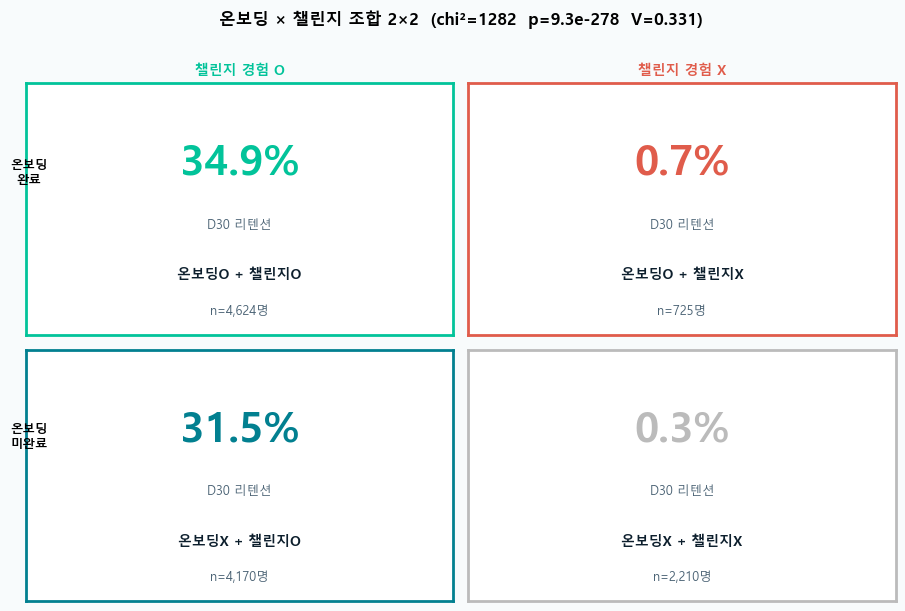

In [16]:

combos = [
    ("온보딩O","챌린지O", sub30[(sub30["has_온보딩_완료"]==1)&(sub30["has_챌린지참여"]==1)]),
    ("온보딩O","챌린지X", sub30[(sub30["has_온보딩_완료"]==1)&(sub30["has_챌린지참여"]==0)]),
    ("온보딩X","챌린지O", sub30[(sub30["has_온보딩_완료"]==0)&(sub30["has_챌린지참여"]==1)]),
    ("온보딩X","챌린지X", sub30[(sub30["has_온보딩_완료"]==0)&(sub30["has_챌린지참여"]==0)]),
]
combo_stats = [(ob, ch, len(df), df["d30"].mean()*100) for ob,ch,df in combos]

ct2 = pd.crosstab(sub30["ob_ch"], sub30["d30"])
chi2_2, p2, _, _ = chi2_contingency(ct2)
v2 = cramers_v(ct2)

colors_2x2 = [MINT, DANGER, TEAL, "#BBBBBB"]
pos = [(0,0),(0,1),(1,0),(1,1)]

fig, axes = plt.subplots(2, 2, figsize=(9, 6))
fig.patch.set_facecolor("#F8FBFC")
for (ob, ch, n, d30), (r,c), color in zip(combo_stats, pos, colors_2x2):
    ax = axes[r][c]
    ax.set_facecolor("white")
    ax.text(0.5, 0.68, f"{d30:.1f}%", transform=ax.transAxes,
            fontsize=30, fontweight="bold", color=color, ha="center", va="center")
    ax.text(0.5, 0.42, "D30 리텐션", transform=ax.transAxes,
            fontsize=9, color=MID, ha="center")
    ax.text(0.5, 0.22, f"{ob} + {ch}", transform=ax.transAxes,
            fontsize=10, fontweight="bold", color=DARK, ha="center")
    ax.text(0.5, 0.08, f"n={n:,}명", transform=ax.transAxes,
            fontsize=9, color=MID, ha="center")
    for spine in ax.spines.values():
        spine.set_edgecolor(color); spine.set_linewidth(2)
    ax.set_xticks([]); ax.set_yticks([])

axes[0][0].set_title("챌린지 경험 O", fontsize=10, fontweight="bold", color=MINT, pad=6)
axes[0][1].set_title("챌린지 경험 X", fontsize=10, fontweight="bold", color=DANGER, pad=6)
fig.text(0.02, 0.72, "온보딩\n완료", ha="center", fontsize=9, fontweight="bold")
fig.text(0.02, 0.28, "온보딩\n미완료", ha="center", fontsize=9, fontweight="bold")
fig.suptitle(f"온보딩 × 챌린지 조합 2×2  (chi²={chi2_2:.0f}  p={p2:.1e}  V={v2:.3f})",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("slide10_onboarding_2x2.png", dpi=180, bbox_inches="tight")
plt.show()


---
## 11장 — 통계 검정 ③ : 알림 빈도의 독립 효과 + 역인과 확인

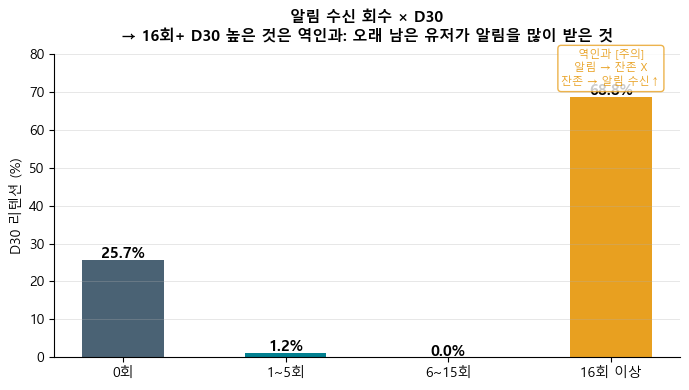

In [17]:

# ── 시각화 1 : 알림 수신 회수 × D30 (역인과) ──
noti_cnt = (
    el_noti[el_noti["Event_Type"]=="알림수신"]
    .groupby("User_ID").size()
    .reset_index(name="noti_cnt")
)
sub_n = sub30.merge(noti_cnt, on="User_ID", how="left")
sub_n["noti_cnt"] = sub_n["noti_cnt"].fillna(0)
sub_n["noti_bucket"] = pd.cut(
    sub_n["noti_cnt"], bins=[-1,0,5,15,9999],
    labels=["0회","1~5회","6~15회","16회 이상"]
)
nb_ret = sub_n.groupby("noti_bucket")["d30"].mean() * 100

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(nb_ret.index, nb_ret.values, color=[MID,TEAL,TEAL,WARN], width=0.5)
for bar, val in zip(bars, nb_ret.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
            f"{val:.1f}%", ha="center", fontsize=11, fontweight="bold")
ax.set_ylim(0, 80)
ax.set_ylabel("D30 리텐션 (%)")
ax.set_title("알림 수신 회수 × D30\n"
             "→ 16회+ D30 높은 것은 역인과: 오래 남은 유저가 알림을 많이 받은 것",
             fontsize=11, fontweight="bold", pad=10)
ax.text(3, nb_ret.iloc[3]+3,
        "역인과 [주의]\n알림 → 잔존 X\n잔존 → 알림 수신↑", ha="center",
        fontsize=8, color=WARN,
        bbox=dict(boxstyle="round", fc="white", ec=WARN, alpha=0.8))
ax.grid(axis="y", alpha=0.3, lw=0.7)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("slide11_noti_reverse_causality.png", dpi=180, bbox_inches="tight")
plt.show()


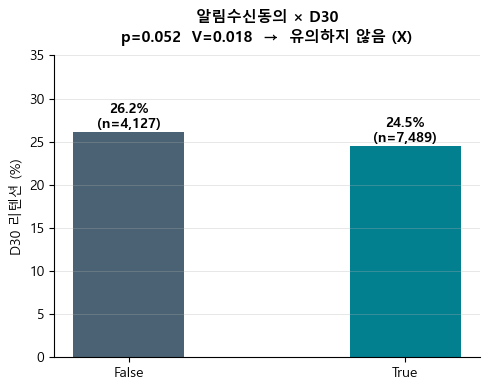

In [18]:

# ── 시각화 2 : 알림 동의 여부 × D30 (장애제외 — 본 결론용) ──
sub_consent = sub30.dropna(subset=["알림수신동의여부"])
grp_n = sub_consent.groupby("알림수신동의여부")["d30"].agg(["mean","count"]).reset_index()
grp_n["D30"] = grp_n["mean"] * 100
ct_n = pd.crosstab(sub_consent["알림수신동의여부"], sub_consent["d30"])
chi2_n, p_n, _, _ = chi2_contingency(ct_n)
v_n = cramers_v(ct_n)

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(grp_n["알림수신동의여부"].astype(str), grp_n["D30"], color=[MID, TEAL], width=0.4)
for bar, row in zip(bars, grp_n.itertuples()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
            f"{row.D30:.1f}%\n(n={row.count:,})", ha="center", fontsize=10, fontweight="bold")
ax.set_ylim(0, 35)
ax.set_ylabel("D30 리텐션 (%)")
sig = "유의하지 않음 (X)" if p_n > 0.05 else "유의함 (O)"
ax.set_title(f"알림수신동의 × D30\np={p_n:.3f}  V={v_n:.3f}  →  {sig}",
             fontsize=11, fontweight="bold", pad=10)
ax.grid(axis="y", alpha=0.3, lw=0.7)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("slide11_noti_consent.png", dpi=180, bbox_inches="tight")
plt.show()


---
## 12장 — 통계 검정 ④ : 전체 검정 종합 (Cramér's V 요약)

              항목     V             p    유의
   기능사용 개수 → D30 0.378  0.000000e+00  True
챌린지+온보딩 조합 → D30 0.331 9.288982e-278  True
  챌린지참여 경험 → D30 0.329 1.592779e-277  True
   식단기록 경험 → D30 0.271 2.101459e-189  True
   운동기록 경험 → D30 0.259 1.637895e-173  True
   마음챙김 경험 → D30 0.227 7.992576e-134  True
   수면기록 경험 → D30 0.173  1.936503e-78  True
 온보딩 완료 여부 → D30 0.110  1.147333e-32  True
    알림수신동의 → D30 0.018  5.186239e-02 False
      가입경로 → D30 0.005  5.743411e-01 False
        기기 → D30 0.004  6.726151e-01 False


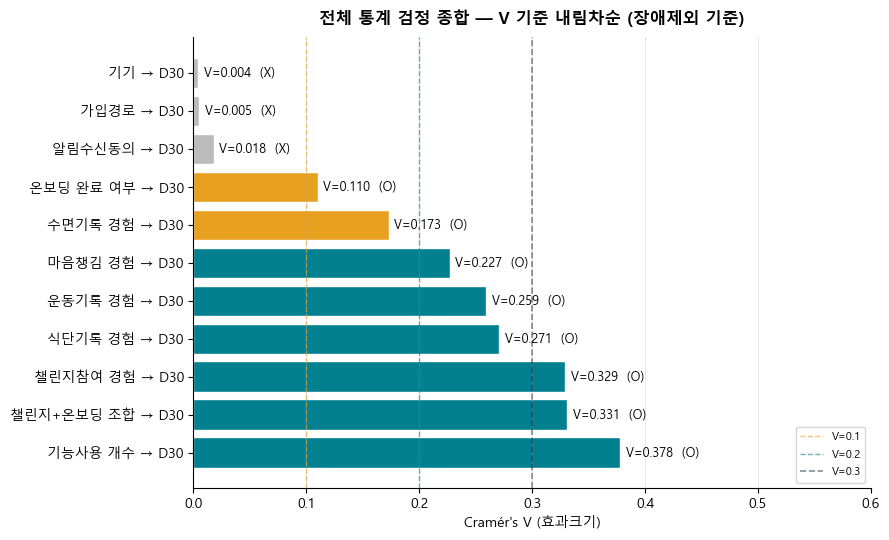

In [19]:

sub_consent = sub30.dropna(subset=["알림수신동의여부"])
test_items = {
    "기능사용 개수 → D30":    pd.crosstab(sub30["category_cnt"],   sub30["d30"]),
    "챌린지+온보딩 조합 → D30": pd.crosstab(sub30["ob_ch"],         sub30["d30"]),
    "챌린지참여 경험 → D30":  pd.crosstab(sub30["has_챌린지참여"], sub30["d30"]),
    "식단기록 경험 → D30":    pd.crosstab(sub30["has_식단기록"],    sub30["d30"]),
    "운동기록 경험 → D30":    pd.crosstab(sub30["has_운동기록"],    sub30["d30"]),
    "마음챙김 경험 → D30":    pd.crosstab(sub30["has_마음챙김"],    sub30["d30"]),
    "수면기록 경험 → D30":    pd.crosstab(sub30["has_수면기록"],    sub30["d30"]),
    "온보딩 완료 여부 → D30": pd.crosstab(sub30["has_온보딩_완료"], sub30["d30"]),
    "알림수신동의 → D30":     pd.crosstab(sub_consent["알림수신동의여부"], sub_consent["d30"]),
    "가입경로 → D30":         pd.crosstab(sub30["가입경로"],        sub30["d30"]),
    "기기 → D30":             pd.crosstab(sub30["기기"],            sub30["d30"]),
}
results = []
for name, ct in test_items.items():
    chi2, p, _, _ = chi2_contingency(ct)
    v = cramers_v(ct)
    results.append({"항목": name, "V": v, "p": p, "유의": p < 0.05})

df_r = pd.DataFrame(results).sort_values("V", ascending=False)
print(df_r.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5.5))
bar_colors = [TEAL if v>=0.2 else WARN if v>=0.1 else "#BBBBBB" for v in df_r["V"]]
bars = ax.barh(df_r["항목"], df_r["V"], color=bar_colors, edgecolor="white")
ax.axvline(0.1, ls="--", color=WARN,   lw=1, alpha=0.6, label="V=0.1")
ax.axvline(0.2, ls="--", color=TEAL,   lw=1, alpha=0.6, label="V=0.2")
ax.axvline(0.3, ls="--", color=DARK,   lw=1.2, alpha=0.5, label="V=0.3")
for bar, row in zip(bars, df_r.itertuples()):
    sig_icon = "(O)" if row.유의 else "(X)"
    ax.text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
            f"V={row.V:.3f}  {sig_icon}", va="center", fontsize=9)
ax.set_xlim(0, 0.6)
ax.set_xlabel("Cramér's V (효과크기)")
ax.set_title("전체 통계 검정 종합 — V 기준 내림차순 (장애제외 기준)",
             fontsize=12, fontweight="bold", pad=10)
ax.legend(fontsize=8, loc="lower right")
ax.grid(axis="x", alpha=0.3, lw=0.7)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("slide12_stats_summary.png", dpi=180, bbox_inches="tight")
plt.show()


---
## 13장 — 심화 EDA : 알림 피로도 + 시간대 + 행동 경로
이 섹션 차트는 D30 계산에 의존하지 않음.

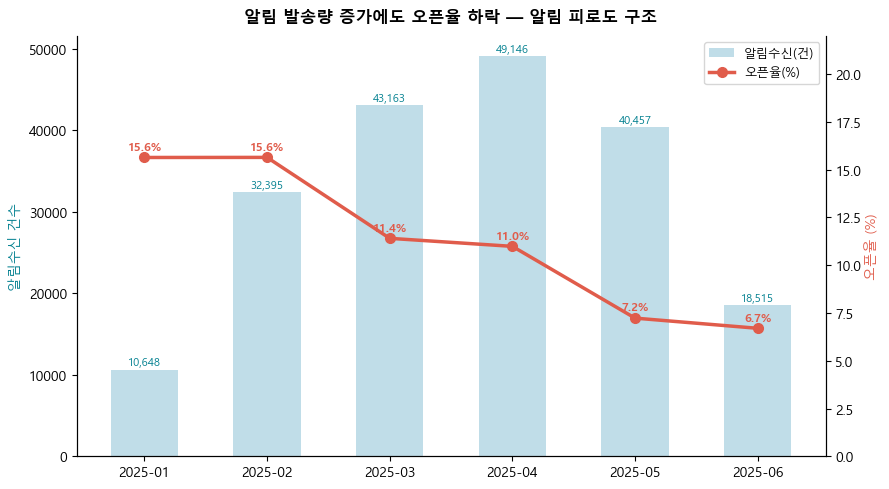

In [20]:

el_noti["Event_Month"] = el_noti["Event_Time"].dt.to_period("M").astype(str)
monthly = el_noti.groupby(["Event_Month","Event_Type"]).size().unstack(fill_value=0)

if "알림수신" in monthly.columns and "알림오픈" in monthly.columns:
    monthly["오픈율"] = monthly["알림오픈"] / monthly["알림수신"] * 100

    fig, ax1 = plt.subplots(figsize=(9, 5))
    ax2 = ax1.twinx()
    x = np.arange(len(monthly))

    ax1.bar(x, monthly["알림수신"], color="#C0DDE8", width=0.55, label="알림수신(건)")
    ax2.plot(x, monthly["오픈율"], color=DANGER, marker="o", lw=2.5, ms=7, label="오픈율(%)")

    for i, (r, o) in enumerate(zip(monthly["알림수신"], monthly["오픈율"])):
        ax1.text(i, r+500, f"{r:,}", ha="center", fontsize=8, color=TEAL)
        ax2.text(i, o+0.4, f"{o:.1f}%", ha="center", fontsize=8.5, color=DANGER, fontweight="bold")

    ax1.set_xticks(x); ax1.set_xticklabels(monthly.index, rotation=0)
    ax1.set_ylabel("알림수신 건수", color=TEAL)
    ax2.set_ylabel("오픈율 (%)", color=DANGER)
    ax2.set_ylim(0, 22)
    ax1.set_title("알림 발송량 증가에도 오픈율 하락 — 알림 피로도 구조",
                  fontsize=12, fontweight="bold", pad=10)
    l1, lb1 = ax1.get_legend_handles_labels()
    l2, lb2 = ax2.get_legend_handles_labels()
    ax1.legend(l1+l2, lb1+lb2, loc="upper right", fontsize=9)
    ax1.spines[["top"]].set_visible(False)
    ax2.spines[["top"]].set_visible(False)
    plt.tight_layout()
    plt.savefig("slide13_noti_fatigue.png", dpi=180, bbox_inches="tight")
    plt.show()


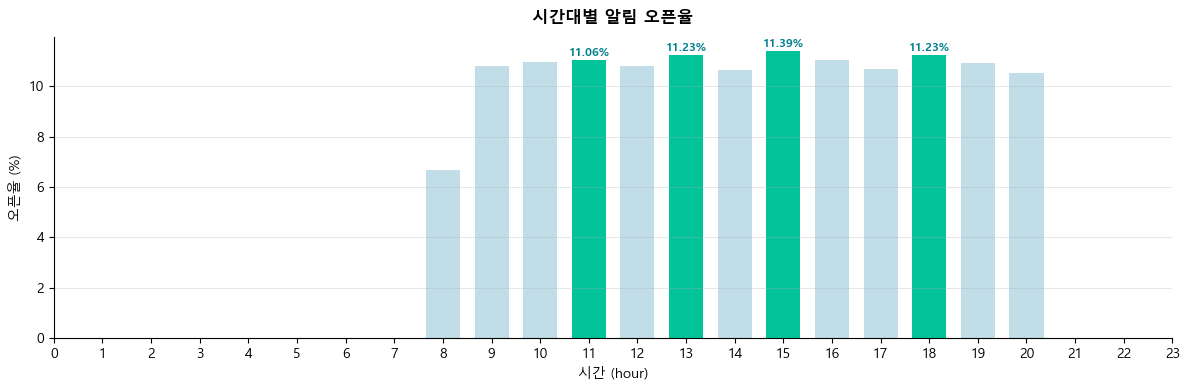

In [21]:

hourly = el_noti.groupby(["Event_Hour","Event_Type"]).size().unstack(fill_value=0)
if "알림수신" in hourly.columns and "알림오픈" in hourly.columns:
    hourly["오픈율"] = hourly["알림오픈"] / hourly["알림수신"] * 100
    top5_hours = hourly["오픈율"].nlargest(5).index

    fig, ax = plt.subplots(figsize=(12, 4))
    bar_c = [MINT if h in top5_hours else "#C0DDE8" for h in hourly.index]
    ax.bar(hourly.index, hourly["오픈율"], color=bar_c, width=0.7)
    for h in top5_hours:
        ax.text(h, hourly.loc[h,"오픈율"]+0.15, f"{hourly.loc[h,'오픈율']:.2f}%",
                ha="center", fontsize=8.5, fontweight="bold", color=TEAL)
    ax.set_xticks(range(0,24))
    ax.set_xlabel("시간 (hour)")
    ax.set_ylabel("오픈율 (%)")
    ax.set_title("시간대별 알림 오픈율", fontsize=12, fontweight="bold", pad=10)
    ax.grid(axis="y", alpha=0.3, lw=0.7)
    ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig("slide13_noti_hour.png", dpi=180, bbox_inches="tight")
    plt.show()


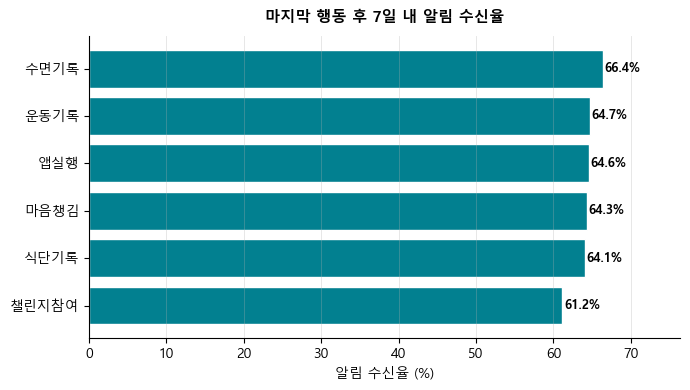

In [22]:

el_j3 = el_act.merge(up[["User_ID","가입일"]], on="User_ID", how="left")
el_j3["days"] = (el_j3["Event_Date"] - el_j3["가입일"]).dt.days
el_ch2 = el_j3[el_j3["User_ID"].isin(churned_ids) & el_j3["days"].between(0,29)]

last_act2 = (
    el_ch2.sort_values("Event_Time")
    .groupby("User_ID")
    .agg(last_type=("Event_Type","last"), last_date=("Event_Date","last"))
    .reset_index()
)

noti_recv = el_noti[el_noti["Event_Type"]=="알림수신"][["User_ID","Event_Date"]].copy()
merged = last_act2.merge(noti_recv, on="User_ID", how="left")
merged["days_after"] = (merged["Event_Date"] - merged["last_date"]).dt.days
has_noti_7d = (
    merged[merged["days_after"].between(0,7)]
    .groupby("User_ID").size().gt(0)
    .reindex(last_act2["User_ID"], fill_value=False)
    .reset_index(name="received")
)
result = last_act2.merge(has_noti_7d, on="User_ID")
receive_rate = result.groupby("last_type")["received"].mean() * 100
receive_rate = receive_rate[receive_rate.index.isin(
    ["앱실행","수면기록","챌린지참여","마음챙김","식단기록","운동기록"]
)].sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(receive_rate.index, receive_rate.values, color=TEAL, edgecolor="white")
for bar, val in zip(bars, receive_rate.values):
    ax.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9, fontweight="bold")
ax.set_xlim(0, max(35, receive_rate.max()*1.15))
ax.set_xlabel("알림 수신율 (%)")
ax.set_title("마지막 행동 후 7일 내 알림 수신율", fontsize=11, fontweight="bold", pad=10)
ax.grid(axis="x", alpha=0.3, lw=0.7)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("slide13_last_action_noti.png", dpi=180, bbox_inches="tight")
plt.show()


---
## 14장 — 타겟 세그먼트 정의 및 실험 설계

챌린지_알림 오픈 유저: 3,657명
기록 행동만 있음       1781
탐색 후 참여          868
앱실행만 있음          481
24시간 내 행동 없음     399
참여만 있음           115
탐색만 있음            13
Name: count, dtype: int64


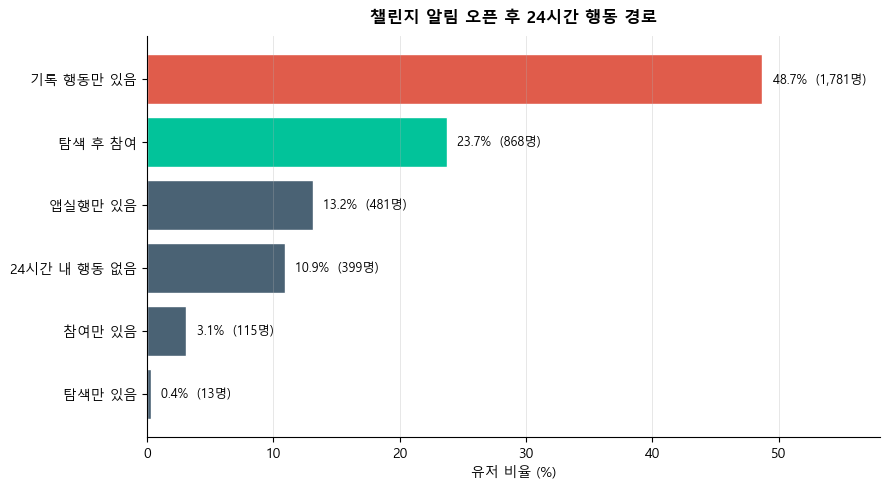

In [23]:

ch_noti_open = el_noti[(el_noti["Event_Type"]=="알림오픈") & (el_noti["알림_유형"]=="챌린지_알림")].copy()
ch_noti_open = ch_noti_open[["User_ID","Event_Time"]].rename(columns={"Event_Time":"open_time"})
ch_noti_open = ch_noti_open.sort_values("open_time").drop_duplicates("User_ID")

merged = el_act.merge(ch_noti_open, on="User_ID", how="inner")
merged["hours_after"] = (merged["Event_Time"] - merged["open_time"]).dt.total_seconds() / 3600
window = merged[merged["hours_after"].between(0, 24)]

def classify(g):
    types = set(g["Event_Type"])
    has_explore = "챌린지_탐색" in types
    has_join    = "챌린지참여" in types
    has_launch  = "앱실행" in types
    has_record  = bool(types & {"수면기록","운동기록","마음챙김","식단기록"})
    if has_explore and has_join: return "탐색 후 참여"
    if has_join and not has_explore: return "참여만 있음"
    if has_explore and not has_join: return "탐색만 있음"
    if has_record: return "기록 행동만 있음"
    if has_launch: return "앱실행만 있음"
    return "24시간 내 행동 없음"

path = window.groupby("User_ID").apply(classify)
all_users = ch_noti_open["User_ID"]
path = path.reindex(all_users, fill_value="24시간 내 행동 없음")
path_dist = path.value_counts()
path_pct  = path_dist / path_dist.sum() * 100
path_pct  = path_pct.sort_values()

print(f"챌린지_알림 오픈 유저: {len(ch_noti_open):,}명")
print(path_dist)

fig, ax = plt.subplots(figsize=(9, 5))
colors = {"기록 행동만 있음":DANGER, "탐색 후 참여":MINT}
bar_colors = [colors.get(i, MID) for i in path_pct.index]
bars = ax.barh(path_pct.index, path_pct.values, color=bar_colors, edgecolor="white")
for bar, p, c in zip(bars, path_pct.values, [path_dist[i] for i in path_pct.index]):
    ax.text(bar.get_width()+0.8, bar.get_y()+bar.get_height()/2,
            f"{p:.1f}%  ({c:,}명)", va="center", fontsize=9)
ax.set_xlim(0, max(58, path_pct.max()*1.15))
ax.set_xlabel("유저 비율 (%)")
ax.set_title("챌린지 알림 오픈 후 24시간 행동 경로",
             fontsize=12, fontweight="bold", pad=10)
ax.grid(axis="x", alpha=0.3, lw=0.7)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("slide14_funnel_leak.png", dpi=180, bbox_inches="tight")
plt.show()


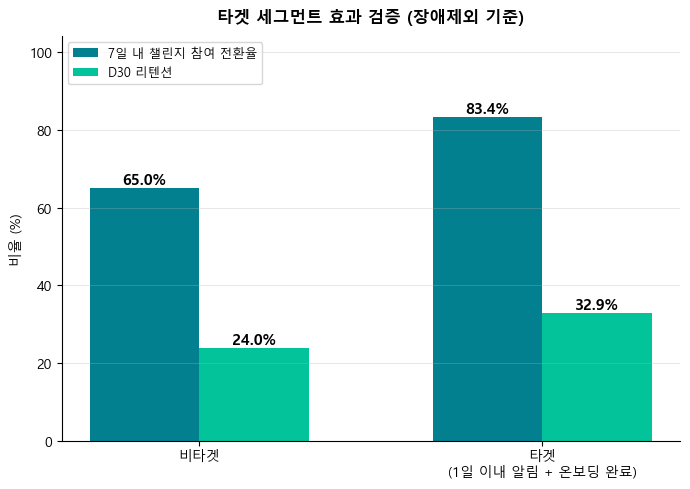

타겟 n=1,597명
전환율: 비타겟 65.0% / 타겟 83.4%  (+18.4%p)
D30:    비타겟 24.0% / 타겟 32.9%  (+9.0%p)


In [24]:

ch_noti_recv = el_noti[(el_noti["Event_Type"]=="알림수신") & (el_noti["알림_유형"]=="챌린지_알림")].copy()
ch_noti_recv = ch_noti_recv.merge(up[["User_ID","가입일"]], on="User_ID", how="left")
ch_noti_recv["days_since_join"] = (ch_noti_recv["Event_Date"] - ch_noti_recv["가입일"]).dt.days
first_recv = ch_noti_recv.sort_values("days_since_join").groupby("User_ID")["days_since_join"].first()

target_ids = set(first_recv[first_recv <= 1].index) & set(ret[ret["has_온보딩_완료"]==1]["User_ID"])
sub30_t = sub30.copy()
sub30_t["is_target"] = sub30_t["User_ID"].isin(target_ids)

ch_join = el_act[el_act["Event_Type"]=="챌린지참여"].merge(up[["User_ID","가입일"]], on="User_ID", how="left")
ch_join["days"] = (ch_join["Event_Date"] - ch_join["가입일"]).dt.days
joined_7d = set(ch_join[ch_join["days"]<=7]["User_ID"])

sub30_t["joined_7d"] = sub30_t["User_ID"].isin(joined_7d)

conv = sub30_t.groupby("is_target")["joined_7d"].mean()*100
d30g = sub30_t.groupby("is_target")["d30"].mean()*100

groups = ["비타겟", "타겟\n(1일 이내 알림 + 온보딩 완료)"]
conv_vals = [conv.loc[False], conv.loc[True]]
d30_vals  = [d30g.loc[False], d30g.loc[True]]

x = np.arange(2); w = 0.32
fig, ax = plt.subplots(figsize=(7, 5))
b1 = ax.bar(x - w/2, conv_vals, w, label="7일 내 챌린지 참여 전환율", color=TEAL)
b2 = ax.bar(x + w/2, d30_vals,  w, label="D30 리텐션", color=MINT)
for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                f"{bar.get_height():.1f}%", ha="center", fontsize=11, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(groups, fontsize=10)
ax.set_ylim(0, max(conv_vals+d30_vals)*1.25)
ax.set_ylabel("비율 (%)")
ax.set_title("타겟 세그먼트 효과 검증 (장애제외 기준)",
             fontsize=12, fontweight="bold", pad=10)
ax.legend(fontsize=9, loc="upper left")
ax.grid(axis="y", alpha=0.3, lw=0.7)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("slide14_target_validated.png", dpi=180, bbox_inches="tight")
plt.show()

print(f"타겟 n={len(target_ids):,}명")
print(f"전환율: 비타겟 {conv_vals[0]:.1f}% / 타겟 {conv_vals[1]:.1f}%  (+{conv_vals[1]-conv_vals[0]:.1f}%p)")
print(f"D30:    비타겟 {d30_vals[0]:.1f}% / 타겟 {d30_vals[1]:.1f}%  (+{d30_vals[1]-d30_vals[0]:.1f}%p)")


---
## 저장 완료 — 총 21개

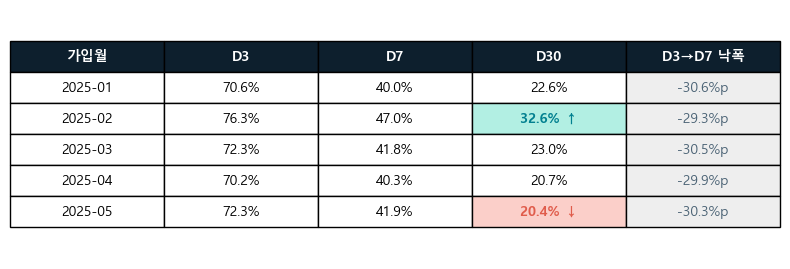

In [25]:
# ── 코호트별 리텐션 테이블형 시각화 (matplotlib table) ──
cs = ret.groupby("cohort")[["d0","d3","d7","d30"]].mean() * 100
cs["n"] = ret.groupby("cohort").size()

columns = ["가입월", "D3", "D7", "D30", "D3→D7 낙폭"]
rows = []
for month, row in cs.iterrows():
    drop = row["d3"] - row["d7"]
    rows.append([
        month,
        f"{row['d3']:.1f}%",
        f"{row['d7']:.1f}%",
        f"{row['d30']:.1f}%" + (" ↑" if row['d30']==cs['d30'].max() else (" ↓" if row['d30']==cs['d30'].min() else "")),
        f"-{drop:.1f}%p"
    ])

fig, ax = plt.subplots(figsize=(8, 2.8))
ax.axis("off")

cell_colors = []
for i, month in enumerate(cs.index):
    row_colors = []
    for j in range(len(columns)):
        if j == 4:
            row_colors.append("#EEEEEE")
        elif j == 3 and cs.loc[month,"d30"] == cs["d30"].max():
            row_colors.append("#B2EFE3")
        elif j == 3 and cs.loc[month,"d30"] == cs["d30"].min():
            row_colors.append("#FBCFC9")
        else:
            row_colors.append("#FFFFFF")
    cell_colors.append(row_colors)

tbl = ax.table(
    cellText=rows,
    colLabels=columns,
    cellColours=cell_colors,
    colColours=[DARK]*5,
    cellLoc="center",
    loc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.6)

for j in range(len(columns)):
    tbl[0, j].set_text_props(color="white", fontweight="bold")

for i, month in enumerate(cs.index):
    if cs.loc[month,"d30"] == cs["d30"].max():
        tbl[i+1, 3].set_text_props(color="#028090", fontweight="bold")
    elif cs.loc[month,"d30"] == cs["d30"].min():
        tbl[i+1, 3].set_text_props(color="#E05C4B", fontweight="bold")

for i in range(1, len(cs)+1):
    tbl[i, 4].set_text_props(color="#4A6274")

plt.tight_layout()
plt.savefig("slide05_cohort_table.png", dpi=180, bbox_inches="tight")
plt.show()